#**Membaca Dataset dan sedikit preprocessing**

In [49]:
import pandas as pd

path_Hotels = 'dataHotel.csv'
df_hotels = pd.read_csv(path_Hotels)

path_Reviews = 'dataReview.csv'
df_reviews = pd.read_csv(path_Reviews)

In [50]:
df_hotels.head()

,hotel_class,name,id,locality,region
0,4.0,Casablanca Hotel Times Square,113317,New York City,NY
1,5.0,Four Seasons Hotel Los Angeles at Beverly Hills,76049,Los Angeles,CA
2,3.5,Hilton Garden Inn Times Square,99352,New York City,NY
3,4.0,The Michelangelo Hotel,93589,New York City,NY
4,4.0,The Muse Hotel New York,217616,New York City,NY


In [51]:
df_reviews.head()

,offering_id,overall,username,user_id
0,93338,5.0,Papa_Panda,8C0B42FF3C0FA366A21CFD785302A032
1,93338,5.0,Maureen V,E3C85CA9DBBBC77E0DB534ABE93E4713
2,1762573,4.0,vuguru,FB1032DECE1162CB3556D05F278AAFFD
3,1762573,4.0,Hotel-Designer,EC3E275EE7590694889C8C7EE0D13961
4,1762573,4.0,JamesE339,BA524A238B1171206691A6CC3F28F266


## Mengecek nilai NaN pada Dataset

In [52]:
print('NaN values in df_hotels:')
display(df_hotels.isna().sum())

NaN values in df_hotels:


hotel_class     0
name            0
id              0
locality       18
region         18
dtype: int64

In [53]:
print('\nNaN values in df_reviews:')
display(df_reviews.isna().sum())


NaN values in df_reviews:


offering_id        0
overall            0
username       77067
user_id        77066
dtype: int64

In [54]:
user_review_counts = df_reviews.groupby('user_id')['offering_id'].nunique().reset_index()
user_review_counts.columns = ['user_id', 'num_rated_hotels']

print("Users who rated the most hotels:")
display(user_review_counts.sort_values(by='num_rated_hotels', ascending=False).head(10))

Users who rated the most hotels:


,user_id,num_rated_hotels
456927,CATID_,258
228309,6562BBD4EA770FE84E579622F68FA181,55
299899,85223AA53CB0DE6A6EB7B3C1E99981B1,52
244141,6C62B19C4DB8C600576B763C68AF0759,48
303175,869E5453ED1ECD12EC2E210BEB6B922E,47
278832,7BC0AF07CC240F2F614A865BBE21B5AA,45
556152,F73CC60121EDAB8E6B1637FDE6A09177,42
53890,17EEAF9A079A2B75E9616F7864F7CA3E,41
36837,106952AB894E1236A6094B030DD73C8F,40
478680,D4B6BB9639B4DFFA8FFD419238D5B805,39


# **Menghitung cosine similarity 1 user dan Menghitung Collaborative filltering**

In [55]:
from sklearn.metrics.pairwise import cosine_similarity

def get_similar_users(user_index, user_item_matrix, top_k=10):
    # ambil vector user X
    user_vector = user_item_matrix[user_index]

    # hitung similarity dengan semua user lain
    similarities = cosine_similarity(user_vector, user_item_matrix).flatten()

    # ambil top K (kecuali dirinya sendiri)
    similar_users = similarities.argsort()[::-1][1:top_k+1]

    return similar_users, similarities[similar_users]

In [56]:
from scipy.sparse import coo_matrix


df_reviews = df_reviews.dropna(subset=['user_id', 'offering_id', 'overall'])
# ubah ke index numerik
user_codes = df_reviews['user_id'].astype('category').cat.codes
item_codes = df_reviews['offering_id'].astype('category').cat.codes
ratings = df_reviews['overall']

# buat sparse matrix (CSR biar cepat akses baris)
user_item_matrix = coo_matrix(
    (ratings, (user_codes, item_codes))
).tocsr()

print(user_item_matrix)

  (0, 67)	4.0
  (0, 126)	5.0
  (0, 404)	4.0
  (0, 519)	5.0
  (0, 990)	4.0
  (0, 2065)	5.0
  (0, 2343)	5.0
  (0, 3232)	2.0
  (1, 266)	4.0
  (2, 3186)	4.0
  (3, 1184)	5.0
  (4, 3380)	5.0
  (5, 833)	5.0
  (6, 2165)	3.0
  (6, 2193)	5.0
  (6, 3115)	3.0
  (7, 1042)	4.0
  (7, 3449)	5.0
  (7, 3578)	5.0
  (8, 224)	1.0
  (8, 3605)	5.0
  (9, 2689)	5.0
  (10, 1373)	4.0
  (11, 1187)	4.0
  (12, 511)	4.0
  :	:
  (575836, 1051)	5.0
  (575837, 3235)	4.0
  (575838, 1964)	5.0
  (575839, 1659)	5.0
  (575840, 3339)	5.0
  (575841, 326)	2.0
  (575842, 1624)	5.0
  (575843, 2221)	4.0
  (575844, 855)	4.0
  (575845, 2100)	5.0
  (575846, 3585)	4.0
  (575847, 345)	4.0
  (575847, 629)	2.0
  (575847, 731)	3.0
  (575847, 1050)	5.0
  (575847, 1769)	5.0
  (575847, 1770)	4.0
  (575847, 2092)	5.0
  (575847, 2101)	3.0
  (575847, 2708)	3.0
  (575848, 798)	4.0
  (575849, 2731)	5.0
  (575850, 1624)	1.0
  (575851, 2759)	5.0
  (575852, 3147)	5.0


In [57]:
user_mapping = dict(enumerate(df_reviews['user_id'].astype('category').cat.categories))
item_mapping = dict(enumerate(df_reviews['offering_id'].astype('category').cat.categories))

In [58]:
#target_user_id = df_reviews['user_id'].iloc[0]
target_user_id = "CATID_"
print(target_user_id)

CATID_


In [59]:
user_to_index = {v: k for k, v in user_mapping.items()}
user_index = user_to_index[target_user_id]

In [60]:
similar_users, scores = get_similar_users(user_index, user_item_matrix, top_k=15)

In [61]:
print("User target:", target_user_id)
print("\nUser paling mirip:")

for idx, score in zip(similar_users, scores):
    print(f"User: {user_mapping[idx]} | Similarity: {score:.4f}")

User target: CATID_

User paling mirip:
User: 19C10DB468D3E94837692BCCAB5C3A12 | Similarity: 0.2528
User: AFD10BAE88FC7D807422E72C49CCE8ED | Similarity: 0.2470
User: 8B5406EDCD85BAD551888DE2B74C05FD | Similarity: 0.2460
User: E9D45BB59ECE9C42E0FFB7663477EDB2 | Similarity: 0.2442
User: AF7DC44BA8AFFD78A5D1001BBD2F4A35 | Similarity: 0.2438
User: 5C9F9887293427145486587CD862FAF7 | Similarity: 0.2438
User: A413897A93C165312D752827C8EC6030 | Similarity: 0.2438
User: 0732BD7189BAD7E97469B025856732A1 | Similarity: 0.2438
User: 32B6F6FB9B23AA24BB42084899E56645 | Similarity: 0.2430
User: 6D25965611FFEBB3939E960AE459CECC | Similarity: 0.2379
User: 5CB9863D6AD8C0DCF0EB06EA0642AB79 | Similarity: 0.2351
User: BDC64E18633E9D3700E9A55CBAE6BAEB | Similarity: 0.2351
User: E399D115E4DA5144E158F59E67A5D670 | Similarity: 0.2351
User: 4952F139DCC1FAEBAC4498EA367D480B | Similarity: 0.2351
User: 4F45AA9B3BCE550E4E64D2CEF0032446 | Similarity: 0.2351


Hotel yang belum dirating oleh user

In [62]:
# rated_hotels_by_target_user = df_reviews[df_reviews['user_id'] == target_user_id]['offering_id'].unique()
# all_unique_hotels = df_reviews['offering_id'].unique()
# unrated_hotels = [hotel for hotel in all_unique_hotels if hotel not in rated_hotels_by_target_user]

# if unrated_hotels:
#     print(f"Hotel yang belum di rating oleh user {target_user_id}:")
#     for hotel_id in unrated_hotels:
#         # Check if the hotel_id exists in df_hotel before trying to merge/display info
#         hotel_info = df_hotels[df_hotels['hotel_id'] == hotel_id]
#         if not hotel_info.empty:
#             print(f"- Hotel ID: {hotel_id}, Class: {hotel_info['hotel_class'].iloc[0]}, Locality: {hotel_info['locality'].iloc[0]}, Region: {hotel_info['Region'].iloc[0]}")
#         else:
#             print(f"- Hotel ID: {hotel_id} (Details not available in df_hotel)")
# else:
#     print(f"User {target_user_id} sudah me-rating semua hotel yang tersedia.")

In [63]:
import numpy as np

def recommend_items(user_index, user_item_matrix, similar_users, scores, top_n=10):
  user_vector = user_item_matrix[user_index].toarray().flatten()
  similar_matrix = user_item_matrix[similar_users].toarray()
  # Hitung weighted sum per item
  weighted_sum = np.dot(scores, similar_matrix)
  # jika user similar merating item, 0 jika tidak
  rated_mask = (similar_matrix > 0).astype(float)
  # Sum similarity hanya untuk user yang merating
  sum_similarity_per_item = np.dot(scores, rated_mask)
  # Hindari pembagian dengan nol
  predicted_ratings = np.where(sum_similarity_per_item > 0, weighted_sum / sum_similarity_per_item,0)
  # Hapus item yang sudah dirating user target
  predicted_ratings[user_vector > 0] = 0
  candidate_items = np.where(predicted_ratings > 0)[0]
  if len(candidate_items) == 0:
      return [], []
  candidate_scores = predicted_ratings[candidate_items]
  top_indices = candidate_scores.argsort()[::-1][:top_n]
  return candidate_items[top_indices], candidate_scores[top_indices]

In [64]:
# import numpy as np

# def recommend_items(user_index, user_item_matrix, similar_users, scores, top_n=5):
#     user_vector = user_item_matrix[user_index].toarray().flatten()
#     similar_matrix = user_item_matrix[similar_users].toarray()

#     weighted_sum = np.dot(scores, similar_matrix)
#     sum_similarity = np.sum(scores)
#     predicted_ratings = weighted_sum / (sum_similarity + 1e-8)

#     predicted_ratings[user_vector > 0] = 0

#     candidate_items = np.where(predicted_ratings > 0)[0]

#     if len(candidate_items) == 0:
#         return [], []

#     candidate_scores = predicted_ratings[candidate_items]

#     # sorting
#     top_indices = candidate_scores.argsort()[::-1][:top_n]

#     return candidate_items[top_indices], candidate_scores[top_indices]

In [65]:
recommended_items, item_scores = recommend_items(
    user_index,
    user_item_matrix,
    similar_users,
    scores,
    top_n=10
)

C:\Users\Basis05\AppData\Local\Temp\ipykernel_5956\628620377.py:13: RuntimeWarning: invalid value encountered in divide
  predicted_ratings = np.where(sum_similarity_per_item > 0, weighted_sum / sum_similarity_per_item,0)


In [66]:
print("\nRekomendasi untuk user:", target_user_id)

for idx, score in zip(recommended_items, item_scores):
    print(f"Hotel: {item_mapping[idx]} | Prediksi Rating: {score:.4f}")


Rekomendasi untuk user: CATID_
Hotel: 111500 | Prediksi Rating: 5.0000
Hotel: 123319 | Prediksi Rating: 4.0000
Hotel: 578190 | Prediksi Rating: 3.0000
Hotel: 114600 | Prediksi Rating: 3.0000


In [67]:
cf_recommendations = pd.DataFrame({
    'hotel_id': [item_mapping[idx] for idx in recommended_items],
    'prediksi_CF': item_scores
})

display(cf_recommendations)

,hotel_id,prediksi_CF
0,111500,5.0
1,123319,4.0
2,578190,3.0
3,114600,3.0


## Preprocessing CBF menambah fitur lebih banyak

In [68]:
avg_rating = df_reviews.groupby('offering_id')['overall'].mean().reset_index()
avg_rating.columns = ['id', 'avg_rating']

In [69]:
review_count = df_reviews.groupby('offering_id')['overall'].count().reset_index()
review_count.columns = ['id', 'review_count']

In [70]:
display(review_count.sort_values(by='review_count', ascending=False).head(10))

,id,review_count
2107,214197,3793
876,93618,3140
845,93520,2995
1964,122005,2842
855,93562,2827
2197,223023,2821
842,93507,2643
3115,611947,2639
2663,249712,2603
1668,111501,2549


In [71]:
df_hotels = df_hotels.merge(avg_rating, on='id', how='left')
df_hotels = df_hotels.merge(review_count, on='id', how='left')

df_hotels['avg_rating'] = df_hotels['avg_rating'].fillna(0)
df_hotels['review_count'] = df_hotels['review_count'].fillna(0)

In [72]:
df_hotels.head()

,hotel_class,name,id,locality,region,avg_rating,review_count
0,4.0,Casablanca Hotel Times Square,113317,New York City,NY,4.743578,2258.0
1,5.0,Four Seasons Hotel Los Angeles at Beverly Hills,76049,Los Angeles,CA,4.596215,317.0
2,3.5,Hilton Garden Inn Times Square,99352,New York City,NY,4.493900,2377.0
3,4.0,The Michelangelo Hotel,93589,New York City,NY,4.540998,1122.0
4,4.0,The Muse Hotel New York,217616,New York City,NY,4.436731,1138.0


In [73]:
# Minmax beberapa kolom
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

df_hotels[['hotel_class', 'avg_rating', 'review_count']] = scaler.fit_transform(
    df_hotels[['hotel_class', 'avg_rating', 'review_count']]
)

df_hotels.head()

,hotel_class,name,id,locality,region,avg_rating,review_count
0,0.750,Casablanca Hotel Times Square,113317,New York City,NY,0.948716,0.595307
1,1.000,Four Seasons Hotel Los Angeles at Beverly Hills,76049,Los Angeles,CA,0.919243,0.083575
2,0.625,Hilton Garden Inn Times Square,99352,New York City,NY,0.898780,0.626681
3,0.750,The Michelangelo Hotel,93589,New York City,NY,0.908200,0.295808
4,0.750,The Muse Hotel New York,217616,New York City,NY,0.887346,0.300026


In [74]:
df_hotels.head()

,hotel_class,name,id,locality,region,avg_rating,review_count
0,0.750,Casablanca Hotel Times Square,113317,New York City,NY,0.948716,0.595307
1,1.000,Four Seasons Hotel Los Angeles at Beverly Hills,76049,Los Angeles,CA,0.919243,0.083575
2,0.625,Hilton Garden Inn Times Square,99352,New York City,NY,0.898780,0.626681
3,0.750,The Michelangelo Hotel,93589,New York City,NY,0.908200,0.295808
4,0.750,The Muse Hotel New York,217616,New York City,NY,0.887346,0.300026


## Memulai CBF

In [75]:
import pandas as pd

# ambil fitur hotel
# hotel_features = df_hotels[['id','hotel_class','locality','region']]
hotel_features = df_hotels[
    ['id','hotel_class','locality','region','avg_rating','review_count']
]

# one-hot encoding
hotel_encoded = pd.get_dummies(
    hotel_features,
    columns=['locality','region']
)
hotel_encoded = hotel_encoded.astype(float)

hotel_encoded

,id,hotel_class,avg_rating,review_count,locality_Austin,locality_Baltimore,locality_Boston,locality_Charlotte,locality_Chicago,locality_Columbus,...,region_MA,region_MD,region_MI,region_NC,region_NY,region_OH,region_PA,region_TN,region_TX,region_WA
0,113317.0,0.750,0.948716,0.595307,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
1,76049.0,1.000,0.919243,0.083575,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,99352.0,0.625,0.898780,0.626681,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
3,93589.0,0.750,0.908200,0.295808,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
4,217616.0,0.750,0.887346,0.300026,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4328,84090.0,1.000,0.910526,0.110203,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4329,84065.0,1.000,0.897000,0.052729,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4330,84093.0,0.750,0.910423,0.485631,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4331,235513.0,0.875,0.914762,0.316109,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [76]:
hotel_encoded = hotel_encoded.set_index('id')

In [77]:
hotel_encoded.head()

,hotel_class,avg_rating,review_count,locality_Austin,locality_Baltimore,locality_Boston,locality_Charlotte,locality_Chicago,locality_Columbus,locality_Dallas,...,region_MA,region_MD,region_MI,region_NC,region_NY,region_OH,region_PA,region_TN,region_TX,region_WA
id,,,,,,,,,,,,,,,,,,,,,
113317.0,0.750,0.948716,0.595307,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
76049.0,1.000,0.919243,0.083575,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
99352.0,0.625,0.898780,0.626681,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
93589.0,0.750,0.908200,0.295808,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
217616.0,0.750,0.887346,0.300026,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0


In [78]:
from sklearn.metrics.pairwise import cosine_similarity

hotel_similarity = cosine_similarity(hotel_encoded)

similarity_hotel_df = pd.DataFrame(
    hotel_similarity,
    index=hotel_encoded.index,
    columns=hotel_encoded.index
)

similarity_hotel_df

id,113317.0,76049.0,99352.0,93589.0,217616.0,208454.0,2643161.0,1465162.0,93559.0,80112.0,...,217770.0,84131.0,84109.0,84118.0,120556.0,84090.0,84065.0,84093.0,235513.0,84117.0
id,,,,,,,,,,,,,,,,,,,,,
113317.0,1.000000,0.436011,0.997885,0.988562,0.988802,0.997892,0.946720,0.996430,0.955391,0.969810,...,0.416331,0.432740,0.388599,0.432098,0.428509,0.438603,0.428205,0.461003,0.455490,0.434979
76049.0,0.436011,1.000000,0.404263,0.439949,0.437008,0.449934,0.385849,0.412304,0.463421,0.440891,...,0.437797,0.460908,0.387158,0.481762,0.439879,0.479958,0.477584,0.435400,0.461364,0.480562
99352.0,0.997885,0.404263,1.000000,0.982416,0.982811,0.993072,0.944593,0.996158,0.942085,0.961081,...,0.390912,0.404573,0.370277,0.399848,0.404164,0.407214,0.395990,0.440924,0.429787,0.403149
93589.0,0.988562,0.439949,0.982416,1.000000,0.999947,0.985524,0.978471,0.994013,0.988099,0.995447,...,0.412654,0.430006,0.378783,0.438876,0.419423,0.440556,0.434456,0.431806,0.440658,0.439351
217616.0,0.988802,0.437008,0.982811,0.999947,1.000000,0.986112,0.977485,0.994096,0.987646,0.995086,...,0.409501,0.427028,0.375253,0.435827,0.416337,0.437691,0.431549,0.429198,0.437918,0.436405
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
84090.0,0.438603,0.479958,0.407214,0.440556,0.437691,0.452807,0.384215,0.414056,0.462118,0.440183,...,0.993136,0.998117,0.968796,0.999405,0.991363,1.000000,0.999554,0.973159,0.992474,0.999857
84065.0,0.428205,0.477584,0.395990,0.434456,0.431549,0.442409,0.381829,0.405221,0.460301,0.436832,...,0.991769,0.996824,0.966371,0.999872,0.988876,0.999554,1.000000,0.966646,0.988737,0.999875
84093.0,0.461003,0.435400,0.440924,0.431806,0.429198,0.470294,0.362920,0.430378,0.418470,0.412194,...,0.984558,0.982815,0.980968,0.966251,0.990384,0.973159,0.966646,1.000000,0.993997,0.969807


In [79]:
user_ratings = df_reviews[['user_id','offering_id','overall']]

In [80]:
user_data = user_ratings[user_ratings['user_id'] == target_user_id]

In [81]:
# Hitung rata rata
# hitung rata-rata rating user (untuk mean-centering)
user_mean = user_data['overall'].mean()

# dictionary hasil prediksi
cbf_predictions = {}

# threshold similarity (bisa kamu ubah)
SIM_THRESHOLD = 0.1


In [82]:
# prediksi CBF
# cbf_predictions = {}

# for hotel in hotel_encoded.index:

#     if hotel not in user_data['offering_id'].values:

#         numerator = 0
#         denominator = 0

#         for _, row in user_data.iterrows():

#             rated_hotel = row['offering_id']
#             rating = row['overall']

#             sim = similarity_hotel_df.loc[hotel, rated_hotel]

#             numerator += sim * rating
#             denominator += sim

#         if denominator != 0:
#             pred = numerator / denominator
#             cbf_predictions[hotel] = pred

In [83]:
for hotel in hotel_encoded.index:

    # skip hotel yang sudah dirating user
    if hotel not in user_data['offering_id'].values:

        numerator = 0
        denominator = 0

        for _, row in user_data.iterrows():

            rated_hotel = row['offering_id']
            rating = row['overall']

            # cek apakah hotel ada di similarity matrix
            if rated_hotel not in similarity_hotel_df.columns:
                continue

            sim = similarity_hotel_df.loc[hotel, rated_hotel]

            # gunakan threshold agar tidak pakai similarity kecil (noise)
            if sim > SIM_THRESHOLD:

                # mean-centering (lebih akademik)
                rating_adj = rating - user_mean

                numerator += sim * rating_adj
                denominator += sim

        # hitung prediksi
        if denominator != 0:
            pred = user_mean + (numerator / denominator)
        else:
            # fallback jika tidak ada similarity
            pred = df_hotels['avg_rating'].mean()

        cbf_predictions[hotel] = pred

In [84]:
# global_mean = df_reviews['overall'].mean()

# cbf_predictions = {}

# for hotel in hotel_encoded.index:

#     if hotel in user_data['offering_id'].values:
#         continue

#     sims = []

#     for _, row in user_data.iterrows():

#         rated_hotel = row['offering_id']
#         rating = row['overall']

#         if rated_hotel not in similarity_hotel_df.columns:
#             continue

#         sim = similarity_hotel_df.loc[hotel, rated_hotel]

#         if sim > 0.2:   # naikkan threshold
#             sims.append((sim, rating))

#     sims = sorted(sims, key=lambda x: x[0], reverse=True)[:5]

#     numerator = 0
#     denominator = 0

#     for sim, rating in sims:
#         numerator += sim * (rating - global_mean)
#         denominator += sim

#     if denominator != 0:
#         pred = global_mean + (numerator / denominator)
#     else:
#         pred = global_mean

#     # clamp
#     pred = max(1, min(5, pred))

#     cbf_predictions[hotel] = pred

In [85]:
cbf_recommendations = sorted(
    cbf_predictions.items(),
    key=lambda x: x[1],
    reverse=True
)

cbf_recommendations[:10]

[(1804281.0, 4.3347669408390015),
 (1940779.0, 4.334698862957024),
 (82992.0, 4.264931449302398),
 (589144.0, 4.2274656948232545),
 (3529145.0, 4.104950141023387),
 (671614.0, 4.104902816504822),
 (3532587.0, 4.0988451276466655),
 (99287.0, 4.096553668741886),
 (1146076.0, 4.085911147491884),
 (3533197.0, 4.085911147491884)]

In [86]:
cbf_recommendations_df = pd.DataFrame(cbf_recommendations, columns=['hotel_id', 'prediksi_CBF'])

df_recommendations = pd.merge(
    cf_recommendations,
    cbf_recommendations_df,
    on='hotel_id',
    how='outer'
)

print("Rekomendasi Gabungan:")
display(df_recommendations)

Rekomendasi Gabungan:


,hotel_id,prediksi_CF,prediksi_CBF
0,72572.0,NaN,3.973825
1,72579.0,NaN,3.975594
2,72586.0,NaN,3.975088
3,72598.0,NaN,3.977701
4,73236.0,NaN,3.890358
...,...,...,...
4070,3583686.0,NaN,4.085911
4071,3584883.0,NaN,3.890070
4072,3613090.0,NaN,4.085911
4073,3627162.0,NaN,3.838056


# **Menghitung Pembobotan Dinamis Hybrid Filltering Test K = 20 dulu**

Mencari Nilai Au ( Alfa U )

In [87]:
num_rated_hotels = user_data.shape[0]
print(f"The target user has rated {num_rated_hotels} hotels.")

The target user has rated 299 hotels.


In [88]:
k_bobot = 15
Au = min((num_rated_hotels / k_bobot), 1) * 0.9
bobot_cf = Au
bobot_cbf = 1 - Au
print(f"Bobot CF {bobot_cf}.")
print(f"Bobot CBF {bobot_cbf}.")

Bobot CF 0.9.
Bobot CBF 0.09999999999999998.


Menghitung Hybrid Pembobotan Dinamis

In [89]:
df_recommendations['hybrid_predict'] = (bobot_cf * df_recommendations['prediksi_CF'].fillna(0) ) + (bobot_cbf * df_recommendations['prediksi_CBF'].fillna(0) )
df_recommendations_sorted = df_recommendations.sort_values(by='hybrid_predict', ascending=False)
display(df_recommendations_sorted)

,hotel_id,prediksi_CF,prediksi_CBF,hybrid_predict
1571,111500.0,5.0,3.981841,4.898184
1959,123319.0,4.0,3.967675,3.996767
1647,114600.0,3.0,3.984618,3.098462
3033,578190.0,3.0,3.973676,3.097368
3863,1804281.0,NaN,4.334767,0.433477
...,...,...,...,...
2630,254242.0,NaN,3.457704,0.345770
3147,634695.0,NaN,3.412004,0.341200
4020,3308100.0,NaN,3.412004,0.341200
3998,2673301.0,NaN,3.412004,0.341200


# **Perhitungan MAE dan RMSE**

## **Evaluasi Rekomendasi Hybrid dengan Leave-One-Out Cross-Validation (LOOCV)**

In [90]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Global mean rating (fallback for CBF if no similar items found)
global_mean_rating = df_reviews['overall'].mean()

# Helper function to get CF prediction for a specific item (since recommend_items gives top_n)
# def get_cf_prediction_for_item(target_user_idx, target_item_code, user_item_matrix_full, similar_users_indices, similarity_scores):
#     # Ensure target_item_code is within valid range for the matrix
#     if target_item_code >= user_item_matrix_full.shape[1]:
#         return global_mean_rating # Item not in matrix, use global mean

#     # Get the vectors for similar users, focusing on the target item's column
#     # Note: user_item_matrix_full is assumed to be the original, full matrix.
#     # The similar_users_indices are found based on the original user_item_matrix.

#     similar_users_ratings_for_item = user_item_matrix_full[similar_users_indices, target_item_code].toarray().flatten()

#     # Calculate weighted sum of ratings from similar users for the target item
#     weighted_sum_ratings = np.dot(similarity_scores, similar_users_ratings_for_item)

#     # Sum of similarities
#     sum_of_similarities = np.sum(similarity_scores)

#     if sum_of_similarities == 0:
#         return global_mean_rating # If no similar users or scores, use global mean

#     predicted_rating = weighted_sum_ratings / sum_of_similarities
#     return predicted_rating

def get_cf_prediction_for_item(
    target_user_idx,
    target_item_code,
    user_item_matrix_full,
    similar_users_indices,
    similarity_scores
):

    # validasi item
    if target_item_code >= user_item_matrix_full.shape[1]:
        return global_mean_rating

    # rating item dari similar users
    similar_users_ratings_for_item = (
        user_item_matrix_full[
            similar_users_indices,
            target_item_code
        ]
        .toarray()
        .flatten()
    )

    # weighted sum
    weighted_sum_ratings = np.dot(
        similarity_scores,
        similar_users_ratings_for_item
    )

    # hanya user yg merating
    rated_mask = (
        similar_users_ratings_for_item > 0
    ).astype(float)

    # normalization PER ITEM
    sum_similarity_per_item = np.dot(
        similarity_scores,
        rated_mask
    )

    # hindari pembagian nol
    if sum_similarity_per_item == 0:
        return global_mean_rating

    predicted_rating = (
        weighted_sum_ratings /
        sum_similarity_per_item
    )

    return predicted_rating


# --- LOOCV Process ---

all_actual_ratings = []
all_predicted_hybrid_ratings = []

# Map offering_id to its numerical code (item_code)
item_to_code = {v: k for k, v in item_mapping.items()}

# Get user_index for the target_user_id
# user_index = user_to_index[target_user_id] # Already defined in a previous cell

# Get all ratings from the target user
target_user_all_ratings = df_reviews[df_reviews['user_id'] == target_user_id]

print(f"Performing LOOCV for user: {target_user_id} with {len(target_user_all_ratings)} ratings.")

for idx, row in target_user_all_ratings.iterrows():
    left_out_offering_id = row['offering_id']
    actual_rating = row['overall']

    # --- Collaborative Filtering (CF) Prediction ---
    # When calculating similarity, we use the full user_item_matrix, as the similarity between users
    # should not be drastically affected by temporarily removing one item for LOOCV.
    # However, for the prediction itself, we need to ensure the left-out item's rating isn't used from the target user.
    # The get_cf_prediction_for_item handles this by taking similar users' ratings.

    # Recalculate similar users and scores with the *original* matrix
    # (User similarity doesn't change by temporarily 'hiding' one rating for LOOCV)
    # The `user_item_matrix` is already defined globally.
    similar_users_cf, scores_cf = get_similar_users(user_index, user_item_matrix, top_k=20)

    left_out_item_code = item_to_code.get(left_out_offering_id)
    if left_out_item_code is None:
        # Skip if item is not found in the item_to_code mapping
        print(f"Warning: Left-out item {left_out_offering_id} not found in item mapping. Skipping.")
        continue

    cf_pred_for_loo_item = get_cf_prediction_for_item(
        user_index,
        left_out_item_code,
        user_item_matrix, # Use the original matrix here for similar users' ratings
        similar_users_cf,
        scores_cf
    )

    # Clamp CF prediction to valid rating range (e.g., 1 to 5)
    cf_pred_for_loo_item = max(1.0, min(5.0, cf_pred_for_loo_item))

    # --- Content-Based Filtering (CBF) Prediction ---
    # Create a temporary user_data_loo by excluding the current left_out_offering_id
    user_data_loo = target_user_all_ratings[target_user_all_ratings['offering_id'] != left_out_offering_id]
    user_mean_loo = user_data_loo['overall'].mean() if not user_data_loo.empty else global_mean_rating

    numerator_cbf = 0
    denominator_cbf = 0

    # Check if the left_out_offering_id exists in the hotel_encoded index
    if left_out_offering_id not in hotel_encoded.index:
        cbf_pred_for_loo_item = global_mean_rating # Item not in CBF model, use global mean
    else:
        for _, ud_row in user_data_loo.iterrows():
            rated_hotel = ud_row['offering_id']
            rating = ud_row['overall']

            # Ensure both left_out_offering_id and rated_hotel exist in the similarity matrix columns
            if rated_hotel in similarity_hotel_df.columns:
                sim = similarity_hotel_df.loc[left_out_offering_id, rated_hotel]
                if sim > SIM_THRESHOLD:
                    rating_adj = rating - user_mean_loo
                    numerator_cbf += sim * rating_adj
                    denominator_cbf += sim

        if denominator_cbf != 0:
            cbf_pred_for_loo_item = user_mean_loo + (numerator_cbf / denominator_cbf)
        else:
            cbf_pred_for_loo_item = global_mean_rating

    # Clamp CBF prediction to valid rating range (e.g., 1 to 5)
    cbf_pred_for_loo_item = max(1.0, min(5.0, cbf_pred_for_loo_item))

    # --- Hybrid Prediction ---
    hybrid_pred_for_loo_item = (bobot_cf * cf_pred_for_loo_item) + (bobot_cbf * cbf_pred_for_loo_item)

    all_actual_ratings.append(actual_rating)
    all_predicted_hybrid_ratings.append(hybrid_pred_for_loo_item)

# Calculate MAE and RMSE
if len(all_actual_ratings) > 0:
    mae = mean_absolute_error(all_actual_ratings, all_predicted_hybrid_ratings)
    rmse = np.sqrt(mean_squared_error(all_actual_ratings, all_predicted_hybrid_ratings))
    print(f"\nEvaluation Results for {target_user_id}:")
    print(f"MAE: {mae:.4f}")
    print(f"RMSE: {rmse:.4f}")
else:
    print(f"No ratings found for {target_user_id} to perform LOOCV evaluation.")


Performing LOOCV for user: CATID_ with 299 ratings.

Evaluation Results for CATID_:
MAE: 0.9410
RMSE: 1.2483


## **Evaluasi Rekomendasi Hybrid dengan Leave-One-Out Cross-Validation (LOOCV) untuk Semua Pengguna**

In [91]:
# from sklearn.metrics import mean_absolute_error, mean_squared_error
# import numpy as np

# # Global mean rating (fallback for CBF if no similar items found)
# global_mean_rating = df_reviews['overall'].mean()

# # Helper function to get CF prediction for a specific item
# def get_cf_prediction_for_item_all_users(target_user_idx, target_item_code, user_item_matrix_full, similar_users_indices, similarity_scores):
#     if target_item_code >= user_item_matrix_full.shape[1] or similar_users_indices.size == 0:
#         return global_mean_rating

#     similar_users_ratings_for_item = user_item_matrix_full[similar_users_indices, target_item_code].toarray().flatten()
#     weighted_sum_ratings = np.dot(similarity_scores, similar_users_ratings_for_item)
#     sum_of_similarities = np.sum(similarity_scores)

#     if sum_of_similarities == 0:
#         return global_mean_rating

#     predicted_rating = weighted_sum_ratings / sum_of_similarities
#     return predicted_rating

# # Helper function for user similarity (re-used)
# def get_similar_users_all_users(user_index, user_item_matrix, top_k=20):
#     user_vector = user_item_matrix[user_index]
#     similarities = cosine_similarity(user_vector, user_item_matrix).flatten()
#     similar_users = similarities.argsort()[::-1][1:top_k+1]
#     return similar_users, similarities[similar_users]

# # --- LOOCV Process for ALL Users ---

# # Lists to store all actual and predicted ratings across all users
# all_overall_actual_ratings = []
# all_overall_predicted_hybrid_ratings = []

# # Map offering_id to its numerical code (item_code)
# item_to_code = {v: k for k, v in item_mapping.items()}

# # Iterate through all unique users
# unique_user_ids = df_reviews['user_id'].unique()

# print(f"Starting LOOCV evaluation for {len(unique_user_ids)} users...")

# for current_user_id in unique_user_ids:
#     # Get user_index for the current user
#     if current_user_id not in user_to_index:
#         print(f"Warning: User {current_user_id} not found in user_to_index. Skipping.")
#         continue
#     current_user_index = user_to_index[current_user_id]

#     # Get all ratings from the current user
#     current_user_all_ratings = df_reviews[df_reviews['user_id'] == current_user_id]

#     if current_user_all_ratings.empty:
#         print(f"Warning: User {current_user_id} has no ratings. Skipping.")
#         continue

#     # Calculate user-specific weights (if 'Au' is dynamic based on num_rated_hotels)
#     num_rated_hotels_current_user = current_user_all_ratings.shape[0]
#     # Using k_bobot from previous cell, or define it if this cell is run independently
#     # Assuming k_bobot = 20 as used previously
#     Au_current = min((num_rated_hotels_current_user / k_bobot), 1) * 0.9
#     bobot_cf_current = Au_current
#     bobot_cbf_current = 1 - Au_current

#     for idx, row in current_user_all_ratings.iterrows():
#         left_out_offering_id = row['offering_id']
#         actual_rating = row['overall']

#         # --- Collaborative Filtering (CF) Prediction ---
#         # Recalculate similar users and scores with the *original* matrix
#         similar_users_cf, scores_cf = get_similar_users_all_users(current_user_index, user_item_matrix, top_k=20)

#         left_out_item_code = item_to_code.get(left_out_offering_id)
#         if left_out_item_code is None:
#             # Skip if item is not found in the item_to_code mapping
#             # print(f"Warning: Left-out item {left_out_offering_id} not found for user {current_user_id}. Skipping this rating.")
#             continue

#         cf_pred_for_loo_item = get_cf_prediction_for_item_all_users(
#             current_user_index,
#             left_out_item_code,
#             user_item_matrix,
#             similar_users_cf,
#             scores_cf
#         )
#         cf_pred_for_loo_item = max(1.0, min(5.0, cf_pred_for_loo_item))

#         # --- Content-Based Filtering (CBF) Prediction ---
#         # Create a temporary user_data_loo by excluding the current left_out_offering_id
#         user_data_loo = current_user_all_ratings[current_user_all_ratings['offering_id'] != left_out_offering_id]
#         user_mean_loo = user_data_loo['overall'].mean() if not user_data_loo.empty else global_mean_rating

#         numerator_cbf = 0
#         denominator_cbf = 0

#         if left_out_offering_id not in hotel_encoded.index:
#             cbf_pred_for_loo_item = global_mean_rating
#         else:
#             for _, ud_row in user_data_loo.iterrows():
#                 rated_hotel = ud_row['offering_id']
#                 rating = ud_row['overall']

#                 if rated_hotel in similarity_hotel_df.columns:
#                     sim = similarity_hotel_df.loc[left_out_offering_id, rated_hotel]
#                     if sim > SIM_THRESHOLD:
#                         rating_adj = rating - user_mean_loo
#                         numerator_cbf += sim * rating_adj
#                         denominator_cbf += sim

#             if denominator_cbf != 0:
#                 cbf_pred_for_loo_item = user_mean_loo + (numerator_cbf / denominator_cbf)
#             else:
#                 cbf_pred_for_loo_item = global_mean_rating

#         cbf_pred_for_loo_item = max(1.0, min(5.0, cbf_pred_for_loo_item))

#         # --- Hybrid Prediction ---
#         hybrid_pred_for_loo_item = (bobot_cf_current * cf_pred_for_loo_item) + (bobot_cbf_current * cbf_pred_for_loo_item)

#         all_overall_actual_ratings.append(actual_rating)
#         all_overall_predicted_hybrid_ratings.append(hybrid_pred_for_loo_item)

# print("LOOCV evaluation for all users completed.")

# # Calculate overall MAE and RMSE
# if len(all_overall_actual_ratings) > 0:
#     overall_mae = mean_absolute_error(all_overall_actual_ratings, all_overall_predicted_hybrid_ratings)
#     overall_rmse = np.sqrt(mean_squared_error(all_overall_actual_ratings, all_overall_predicted_hybrid_ratings))
#     print(f"\nOverall Evaluation Results for All Users:")
#     print(f"Total ratings evaluated: {len(all_overall_actual_ratings)}")
#     print(f"Overall MAE: {overall_mae:.4f}")
#     print(f"Overall RMSE: {overall_rmse:.4f}")
# else:
#     print(f"No ratings found across all users for LOOCV evaluation.")


## **Evaluasi LOOCV untuk Satu Pengguna dengan Berbagai Nilai K (Jumlah Pengguna Mirip)**

Untuk mengoptimalkan sistem rekomendasi, kita akan mengevaluasi kinerja model hybrid (MAE dan RMSE) untuk `target_user_id` yang sudah ditentukan, dengan memvariasikan jumlah pengguna mirip (`top_k`) yang digunakan dalam Collaborative Filtering.

In [92]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# Define the range of K values to test
k_values_to_test = [5, 10, 15, 20, 25, 30, 40, 50] # yang terbaik adalah 10 dengan nilai K pada bobot dinamis dengan K pada cf berubah
#k_values_to_test = [75, 100,150 ,200 ,250, 300, 400 , 500] # yang terbaik adalah 500 dengan nilai K pada bobot dinamis dengan K pada cf berubah
# k_values_to_test = [600, 700,800 ,900 ,1000] # yang terbaik adalah K = 1000 dengan mengubah nilai K pada pembobotan dinamis

results_k_tuning = []

# Re-use helper function from previous cell for CF prediction for a specific item
# global_mean_rating, get_cf_prediction_for_item, get_similar_users, user_to_index,
# item_mapping, item_to_code, df_reviews, user_item_matrix, hotel_encoded,
# similarity_hotel_df, SIM_THRESHOLD, bobot_cf, bobot_cbf are assumed to be in scope

print(f"Starting K-tuning LOOCV evaluation for user: {target_user_id}")

# Get all ratings from the target user once
target_user_all_ratings = df_reviews[df_reviews['user_id'] == target_user_id]

if target_user_all_ratings.empty:
    print(f"No ratings found for {target_user_id}. Cannot perform K-tuning evaluation.")
else:
    for current_k in k_values_to_test:
        print(f"\nEvaluating with K = {current_k}...")

        all_actual_ratings_k = []
        all_predicted_hybrid_ratings_k = []

        # Get user_index for the target_user_id
        current_user_index = user_to_index[target_user_id]

        # --- Calculate user-specific weights (Au will now depend on current_k) ---
        num_rated_hotels_current_user = target_user_all_ratings.shape[0]
        # k_bobot now equals current_k as per user's request
        Au_current = min((num_rated_hotels_current_user / current_k), 1) * 0.9
        bobot_cf_current = Au_current
        bobot_cbf_current = 1 - Au_current

        for idx, row in target_user_all_ratings.iterrows():
            left_out_offering_id = row['offering_id']
            actual_rating = row['overall']

            # --- Collaborative Filtering (CF) Prediction ---
            similar_users_cf, scores_cf = get_similar_users(current_user_index, user_item_matrix, top_k=current_k) # current_k

            left_out_item_code = item_to_code.get(left_out_offering_id)
            if left_out_item_code is None:
                continue

            cf_pred_for_loo_item = get_cf_prediction_for_item(
                current_user_index,
                left_out_item_code,
                user_item_matrix,
                similar_users_cf,
                scores_cf
            )
            cf_pred_for_loo_item = max(1.0, min(5.0, cf_pred_for_loo_item))

            # --- Content-Based Filtering (CBF) Prediction ---
            user_data_loo = target_user_all_ratings[target_user_all_ratings['offering_id'] != left_out_offering_id]
            user_mean_loo = user_data_loo['overall'].mean() if not user_data_loo.empty else global_mean_rating

            numerator_cbf = 0
            denominator_cbf = 0

            if left_out_offering_id not in hotel_encoded.index:
                cbf_pred_for_loo_item = global_mean_rating
            else:
                for _, ud_row in user_data_loo.iterrows():
                    rated_hotel = ud_row['offering_id']
                    rating = ud_row['overall']

                    if rated_hotel in similarity_hotel_df.columns:
                        sim = similarity_hotel_df.loc[left_out_offering_id, rated_hotel]
                        if sim > SIM_THRESHOLD:
                            rating_adj = rating - user_mean_loo
                            numerator_cbf += sim * rating_adj
                            denominator_cbf += sim

                if denominator_cbf != 0:
                    cbf_pred_for_loo_item = user_mean_loo + (numerator_cbf / denominator_cbf)
                else:
                    cbf_pred_for_loo_item = global_mean_rating

            cbf_pred_for_loo_item = max(1.0, min(5.0, cbf_pred_for_loo_item))

            # --- Hybrid Prediction ---
            hybrid_pred_for_loo_item = (bobot_cf_current * cf_pred_for_loo_item) + (bobot_cbf_current * cbf_pred_for_loo_item)

            all_actual_ratings_k.append(actual_rating)
            all_predicted_hybrid_ratings_k.append(hybrid_pred_for_loo_item)

        # Calculate MAE and RMSE for the current K
        if len(all_actual_ratings_k) > 0:
            mae_k = mean_absolute_error(all_actual_ratings_k, all_predicted_hybrid_ratings_k)
            rmse_k = np.sqrt(mean_squared_error(all_actual_ratings_k, all_predicted_hybrid_ratings_k))
            results_k_tuning.append({'K': current_k, 'MAE': mae_k, 'RMSE': rmse_k})
            print(f"  MAE (K={current_k}): {mae_k:.4f}")
            print(f"  RMSE (K={current_k}): {rmse_k:.4f}")
        else:
            print(f"  No ratings evaluated for K={current_k}.")

    # Display all results
    print("\n--- K-Tuning Results Summary ---")
    for result in results_k_tuning:
        print(f"K: {result['K']}, MAE: {result['MAE']:.4f}, RMSE: {result['RMSE']:.4f}")

    # Find best K based on MAE
    if results_k_tuning:
        best_k_mae = min(results_k_tuning, key=lambda x: x['MAE'])
        print(f"\nBest K (based on MAE): {best_k_mae['K']} with MAE = {best_k_mae['MAE']:.4f}")

Starting K-tuning LOOCV evaluation for user: CATID_

Evaluating with K = 5...
  MAE (K=5): 0.9188
  RMSE (K=5): 1.2152

Evaluating with K = 10...
  MAE (K=10): 0.9122
  RMSE (K=10): 1.2002

Evaluating with K = 15...
  MAE (K=15): 0.9119
  RMSE (K=15): 1.1988

Evaluating with K = 20...
  MAE (K=20): 0.9410
  RMSE (K=20): 1.2483

Evaluating with K = 25...
  MAE (K=25): 0.9369
  RMSE (K=25): 1.2426

Evaluating with K = 30...
  MAE (K=30): 0.9369
  RMSE (K=30): 1.2426

Evaluating with K = 40...
  MAE (K=40): 0.9369
  RMSE (K=40): 1.2426

Evaluating with K = 50...
  MAE (K=50): 0.9369
  RMSE (K=50): 1.2427

--- K-Tuning Results Summary ---
K: 5, MAE: 0.9188, RMSE: 1.2152
K: 10, MAE: 0.9122, RMSE: 1.2002
K: 15, MAE: 0.9119, RMSE: 1.1988
K: 20, MAE: 0.9410, RMSE: 1.2483
K: 25, MAE: 0.9369, RMSE: 1.2426
K: 30, MAE: 0.9369, RMSE: 1.2426
K: 40, MAE: 0.9369, RMSE: 1.2426
K: 50, MAE: 0.9369, RMSE: 1.2427

Best K (based on MAE): 15 with MAE = 0.9119


# **Semua di evaluasi untuk 1 user**

In [93]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# Range nilai K yang ingin diuji
k_values_to_test = [5, 10, 15, 20, 25, 30, 40, 50]

results_k_tuning = []

print(f"Starting K-tuning LOOCV evaluation for user: {target_user_id}")

# Ambil semua rating dari user target
target_user_all_ratings = df_reviews[df_reviews['user_id'] == target_user_id]

if target_user_all_ratings.empty:
    print(f"No ratings found for {target_user_id}. Cannot perform evaluation.")
else:
    for current_k in k_values_to_test:
        print(f"\nEvaluating with K = {current_k}...")

        all_actual_ratings = []

        # Untuk masing-masing metode
        all_predicted_cf = []
        all_predicted_cbf = []
        all_predicted_hybrid = []

        current_user_index = user_to_index[target_user_id]

        # Hitung bobot dinamis
        num_rated = target_user_all_ratings.shape[0]
        Au = min((num_rated / current_k), 1) * 0.9
        bobot_cf = Au
        bobot_cbf = 1 - Au

        for idx, row in target_user_all_ratings.iterrows():
            left_out_offering_id = row['offering_id']
            actual_rating = row['overall']

            # ======================
            # CF PREDICTION
            # ======================
            similar_users_cf, scores_cf = get_similar_users(
                current_user_index,
                user_item_matrix,
                top_k=current_k
            )

            left_out_item_code = item_to_code.get(left_out_offering_id)
            if left_out_item_code is None:
                continue

            cf_pred = get_cf_prediction_for_item(
                current_user_index,
                left_out_item_code,
                user_item_matrix,
                similar_users_cf,
                scores_cf
            )
            cf_pred = max(1.0, min(5.0, cf_pred))

            # ======================
            # CBF PREDICTION
            # ======================
            user_data_loo = target_user_all_ratings[
                target_user_all_ratings['offering_id'] != left_out_offering_id
            ]

            user_mean = user_data_loo['overall'].mean() if not user_data_loo.empty else global_mean_rating

            numerator = 0
            denominator = 0

            if left_out_offering_id not in hotel_encoded.index:
                cbf_pred = global_mean_rating
            else:
                for _, ud_row in user_data_loo.iterrows():
                    rated_hotel = ud_row['offering_id']
                    rating = ud_row['overall']

                    if rated_hotel in similarity_hotel_df.columns:
                        sim = similarity_hotel_df.loc[left_out_offering_id, rated_hotel]

                        if sim > SIM_THRESHOLD:
                            numerator += sim * (rating - user_mean)
                            denominator += sim

                if denominator != 0:
                    cbf_pred = user_mean + (numerator / denominator)
                else:
                    cbf_pred = global_mean_rating

            cbf_pred = max(1.0, min(5.0, cbf_pred))

            # ======================
            # HYBRID PREDICTION
            # ======================
            hybrid_pred = (bobot_cf * cf_pred) + (bobot_cbf * cbf_pred)

            # Simpan semua
            all_actual_ratings.append(actual_rating)
            all_predicted_cf.append(cf_pred)
            all_predicted_cbf.append(cbf_pred)
            all_predicted_hybrid.append(hybrid_pred)

        # ======================
        # HITUNG METRIK
        # ======================
        if len(all_actual_ratings) > 0:

            # CF
            mae_cf = mean_absolute_error(all_actual_ratings, all_predicted_cf)
            rmse_cf = np.sqrt(mean_squared_error(all_actual_ratings, all_predicted_cf))

            # CBF
            mae_cbf = mean_absolute_error(all_actual_ratings, all_predicted_cbf)
            rmse_cbf = np.sqrt(mean_squared_error(all_actual_ratings, all_predicted_cbf))

            # Hybrid
            mae_hybrid = mean_absolute_error(all_actual_ratings, all_predicted_hybrid)
            rmse_hybrid = np.sqrt(mean_squared_error(all_actual_ratings, all_predicted_hybrid))

            results_k_tuning.append({
                'K': current_k,
                'MAE_CF': mae_cf,
                'RMSE_CF': rmse_cf,
                'MAE_CBF': mae_cbf,
                'RMSE_CBF': rmse_cbf,
                'MAE_HYBRID': mae_hybrid,
                'RMSE_HYBRID': rmse_hybrid
            })

            print(f"  CF     -> MAE: {mae_cf:.4f}, RMSE: {rmse_cf:.4f}")
            print(f"  CBF    -> MAE: {mae_cbf:.4f}, RMSE: {rmse_cbf:.4f}")
            print(f"  HYBRID -> MAE: {mae_hybrid:.4f}, RMSE: {rmse_hybrid:.4f}")

        else:
            print(f"  No ratings evaluated for K={current_k}")

    # ======================
    # SUMMARY
    # ======================
    print("\n--- K-Tuning Results Summary ---")
    for result in results_k_tuning:
        print(f"""
K: {result['K']}
  CF     -> MAE: {result['MAE_CF']:.4f}, RMSE: {result['RMSE_CF']:.4f}
  CBF    -> MAE: {result['MAE_CBF']:.4f}, RMSE: {result['RMSE_CBF']:.4f}
  HYBRID -> MAE: {result['MAE_HYBRID']:.4f}, RMSE: {result['RMSE_HYBRID']:.4f}
""")

    # ======================
    # BEST K (HYBRID)
    # ======================
    if results_k_tuning:
        best_k = min(results_k_tuning, key=lambda x: x['MAE_HYBRID'])
        print(f"\nBest K (Hybrid - MAE): {best_k['K']} with MAE = {best_k['MAE_HYBRID']:.4f}")

Starting K-tuning LOOCV evaluation for user: CATID_

Evaluating with K = 5...
  CF     -> MAE: 0.9204, RMSE: 1.2201
  CBF    -> MAE: 0.9078, RMSE: 1.1959
  HYBRID -> MAE: 0.9188, RMSE: 1.2152

Evaluating with K = 10...
  CF     -> MAE: 0.9133, RMSE: 1.2034
  CBF    -> MAE: 0.9078, RMSE: 1.1959
  HYBRID -> MAE: 0.9122, RMSE: 1.2002

Evaluating with K = 15...
  CF     -> MAE: 0.9129, RMSE: 1.2015
  CBF    -> MAE: 0.9078, RMSE: 1.1959
  HYBRID -> MAE: 0.9119, RMSE: 1.1988

Evaluating with K = 20...
  CF     -> MAE: 0.9452, RMSE: 1.2599
  CBF    -> MAE: 0.9078, RMSE: 1.1959
  HYBRID -> MAE: 0.9410, RMSE: 1.2483

Evaluating with K = 25...
  CF     -> MAE: 0.9407, RMSE: 1.2532
  CBF    -> MAE: 0.9078, RMSE: 1.1959
  HYBRID -> MAE: 0.9369, RMSE: 1.2426

Evaluating with K = 30...
  CF     -> MAE: 0.9407, RMSE: 1.2531
  CBF    -> MAE: 0.9078, RMSE: 1.1959
  HYBRID -> MAE: 0.9369, RMSE: 1.2426

Evaluating with K = 40...
  CF     -> MAE: 0.9407, RMSE: 1.2531
  CBF    -> MAE: 0.9078, RMSE: 1.1959


# **Evaluasi Semua user**

In [94]:
# from sklearn.metrics import mean_absolute_error, mean_squared_error
# import matplotlib.pyplot as plt
# import pandas as pd
# import numpy as np

# # =====================================================
# # RANGE K
# # =====================================================
# k_values_to_test = [5, 10, 15, 20, 25, 30, 40, 50]

# # =====================================================
# # GLOBAL MEAN
# # =====================================================
# global_mean_rating = df_reviews['overall'].mean()

# # =====================================================
# # SIMPAN HASIL
# # =====================================================
# results_k_tuning = []

# # =====================================================
# # LOOP K
# # =====================================================
# for current_k in k_values_to_test:

#     print(f"\nEvaluating K = {current_k}")

#     # ================================================
#     # LIST PENYIMPAN
#     # ================================================
#     all_actual_ratings = []

#     all_predicted_cf = []
#     all_predicted_cbf = []
#     all_predicted_hybrid = []

#     # ================================================
#     # LOOP USER
#     # ================================================
#     unique_user_ids = df_reviews['user_id'].unique()

#     for current_user_id in unique_user_ids:

#         if current_user_id not in user_to_index:
#             continue

#         current_user_index = user_to_index[current_user_id]

#         current_user_all_ratings = df_reviews[
#             df_reviews['user_id'] == current_user_id
#         ]

#         if current_user_all_ratings.empty:
#             continue

#         # ============================================
#         # BOBOT DINAMIS
#         # ============================================
#         num_rated = current_user_all_ratings.shape[0]

#         Au = min((num_rated / current_k), 1) * 0.9

#         bobot_cf = Au
#         bobot_cbf = 1 - Au

#         # ============================================
#         # LOOCV
#         # ============================================
#         for idx, row in current_user_all_ratings.iterrows():

#             left_out_offering_id = row['offering_id']
#             actual_rating = row['overall']

#             # ========================================
#             # CF
#             # ========================================
#             similar_users_cf, scores_cf = (
#                 get_similar_users_all_users(
#                     current_user_index,
#                     user_item_matrix,
#                     top_k=current_k
#                 )
#             )

#             left_out_item_code = item_to_code.get(
#                 left_out_offering_id
#             )

#             if left_out_item_code is None:
#                 continue

#             cf_pred = get_cf_prediction_for_item_all_users(
#                 current_user_index,
#                 left_out_item_code,
#                 user_item_matrix,
#                 similar_users_cf,
#                 scores_cf
#             )

#             cf_pred = max(1.0, min(5.0, cf_pred))

#             # ========================================
#             # CBF
#             # ========================================
#             user_data_loo = current_user_all_ratings[
#                 current_user_all_ratings['offering_id']
#                 != left_out_offering_id
#             ]

#             user_mean = (
#                 user_data_loo['overall'].mean()
#                 if not user_data_loo.empty
#                 else global_mean_rating
#             )

#             numerator = 0
#             denominator = 0

#             if left_out_offering_id not in hotel_encoded.index:

#                 cbf_pred = global_mean_rating

#             else:

#                 for _, ud_row in user_data_loo.iterrows():

#                     rated_hotel = ud_row['offering_id']
#                     rating = ud_row['overall']

#                     if rated_hotel in similarity_hotel_df.columns:

#                         sim = similarity_hotel_df.loc[
#                             left_out_offering_id,
#                             rated_hotel
#                         ]

#                         if sim > SIM_THRESHOLD:

#                             numerator += sim * (
#                                 rating - user_mean
#                             )

#                             denominator += sim

#                 if denominator != 0:

#                     cbf_pred = (
#                         user_mean +
#                         (numerator / denominator)
#                     )

#                 else:

#                     cbf_pred = global_mean_rating

#             cbf_pred = max(1.0, min(5.0, cbf_pred))

#             # ========================================
#             # HYBRID
#             # ========================================
#             hybrid_pred = (
#                 (bobot_cf * cf_pred)
#                 +
#                 (bobot_cbf * cbf_pred)
#             )

#             # ========================================
#             # SIMPAN
#             # ========================================
#             all_actual_ratings.append(actual_rating)

#             all_predicted_cf.append(cf_pred)
#             all_predicted_cbf.append(cbf_pred)
#             all_predicted_hybrid.append(hybrid_pred)

#     # =================================================
#     # HITUNG METRIK
#     # =================================================

#     mae_cf = mean_absolute_error(
#         all_actual_ratings,
#         all_predicted_cf
#     )

#     rmse_cf = np.sqrt(
#         mean_squared_error(
#             all_actual_ratings,
#             all_predicted_cf
#         )
#     )

#     mae_cbf = mean_absolute_error(
#         all_actual_ratings,
#         all_predicted_cbf
#     )

#     rmse_cbf = np.sqrt(
#         mean_squared_error(
#             all_actual_ratings,
#             all_predicted_cbf
#         )
#     )

#     mae_hybrid = mean_absolute_error(
#         all_actual_ratings,
#         all_predicted_hybrid
#     )

#     rmse_hybrid = np.sqrt(
#         mean_squared_error(
#             all_actual_ratings,
#             all_predicted_hybrid
#         )
#     )

#     # =================================================
#     # SIMPAN HASIL
#     # =================================================
#     results_k_tuning.append({
#         'K': current_k,
#         'MAE_CF': mae_cf,
#         'RMSE_CF': rmse_cf,
#         'MAE_CBF': mae_cbf,
#         'RMSE_CBF': rmse_cbf,
#         'MAE_HYBRID': mae_hybrid,
#         'RMSE_HYBRID': rmse_hybrid
#     })

# # =====================================================
# # DATAFRAME
# # =====================================================
# results_df = pd.DataFrame(results_k_tuning)

# print("\n===== HASIL K-TUNING =====")
# print(results_df)

# # =====================================================
# # CARI K TERBAIK
# # =====================================================
# best_k = results_df.loc[
#     results_df['MAE_HYBRID'].idxmin()
# ]

# print("\n===== BEST K =====")
# print(best_k)

# # =====================================================
# # GRAFIK MAE
# # =====================================================
# plt.figure(figsize=(10,6))

# plt.plot(
#     results_df['K'],
#     results_df['MAE_CF'],
#     marker='o',
#     label='CF'
# )

# plt.plot(
#     results_df['K'],
#     results_df['MAE_CBF'],
#     marker='o',
#     label='CBF'
# )

# plt.plot(
#     results_df['K'],
#     results_df['MAE_HYBRID'],
#     marker='o',
#     label='Hybrid'
# )

# plt.xlabel('Nilai K')
# plt.ylabel('MAE')

# plt.title('Perbandingan MAE terhadap Nilai K')

# plt.legend()

# plt.grid(True)

# plt.show()

# # =====================================================
# # GRAFIK RMSE
# # =====================================================
# plt.figure(figsize=(10,6))

# plt.plot(
#     results_df['K'],
#     results_df['RMSE_CF'],
#     marker='o',
#     label='CF'
# )

# plt.plot(
#     results_df['K'],
#     results_df['RMSE_CBF'],
#     marker='o',
#     label='CBF'
# )

# plt.plot(
#     results_df['K'],
#     results_df['RMSE_HYBRID'],
#     marker='o',
#     label='Hybrid'
# )

# plt.xlabel('Nilai K')
# plt.ylabel('RMSE')

# plt.title('Perbandingan RMSE terhadap Nilai K')

# plt.legend()

# plt.grid(True)

# plt.show()

EVALUASI UNTUK USER YANG MERATING LEBIH DARI 5 saja ( TERDAPAT 7000 USER YANG DIEVALUASI )

In [95]:
# # =========================================================
# # IMPORT LIBRARY
# # =========================================================
# import pandas as pd
# import numpy as np
# import matplotlib.pyplot as plt

# from sklearn.metrics import (
#     mean_absolute_error,
#     mean_squared_error
# )

# # =========================================================
# # ACTIVE USERS (>5 RATING)
# # =========================================================
# user_rating_counts = df_reviews['user_id'].value_counts()

# active_users = user_rating_counts[
#     user_rating_counts > 5
# ].index

# print("===== ACTIVE USER INFO =====")

# print(f"Total Seluruh User : {df_reviews['user_id'].nunique()}")

# print(f"Total Active Users (>5 rating) : {len(active_users)}")

# # =========================================================
# # GLOBAL MEAN
# # =========================================================
# global_mean_rating = df_reviews['overall'].mean()

# # =========================================================
# # K VALUES
# # =========================================================
# k_values_to_test = [5, 10, 15, 20, 25, 30, 40, 50]

# # =========================================================
# # RESULT STORAGE
# # =========================================================
# results_k_tuning = []

# # =========================================================
# # LOOP K
# # =========================================================
# for current_k in k_values_to_test:

#     print("\n===================================")
#     print(f"Evaluating K = {current_k}")
#     print("===================================")

#     # ================================================
#     # PENYIMPAN
#     # ================================================
#     all_actual_ratings = []

#     all_predicted_cf = []
#     all_predicted_cbf = []
#     all_predicted_hybrid = []

#     # ================================================
#     # LOOP ACTIVE USERS ONLY
#     # ================================================
#     for target_user_id in active_users:

#         # Pastikan user ada di mapping
#         if target_user_id not in user_to_index:
#             continue

#         current_user_index = user_to_index[
#             target_user_id
#         ]

#         # ============================================
#         # Ambil semua rating user
#         # ============================================
#         target_user_all_ratings = df_reviews[
#             df_reviews['user_id']
#             == target_user_id
#         ]

#         if target_user_all_ratings.empty:
#             continue

#         # ============================================
#         # Dynamic Weight
#         # ============================================
#         num_rated = target_user_all_ratings.shape[0]

#         Au = min(
#             (num_rated / current_k),
#             1
#         ) * 0.9

#         bobot_cf = Au
#         bobot_cbf = 1 - Au

#         # ============================================
#         # LOOCV
#         # ============================================
#         for idx, row in target_user_all_ratings.iterrows():

#             left_out_offering_id = row['offering_id']

#             actual_rating = row['overall']

#             # ========================================
#             # CF PREDICTION
#             # ========================================

#             # =================================================
#             # PENTING:
#             # similarity tetap memakai SEMUA USER
#             # karena user_item_matrix full dataset
#             # =================================================
#             similar_users_cf, scores_cf = (
#                 get_similar_users(
#                     current_user_index,
#                     user_item_matrix,
#                     top_k=current_k
#                 )
#             )

#             left_out_item_code = item_to_code.get(
#                 left_out_offering_id
#             )

#             if left_out_item_code is None:
#                 continue

#             cf_pred = get_cf_prediction_for_item(
#                 current_user_index,
#                 left_out_item_code,
#                 user_item_matrix,
#                 similar_users_cf,
#                 scores_cf
#             )

#             cf_pred = max(
#                 1.0,
#                 min(5.0, cf_pred)
#             )

#             # ========================================
#             # CBF PREDICTION
#             # ========================================
#             user_data_loo = (
#                 target_user_all_ratings[
#                     target_user_all_ratings[
#                         'offering_id'
#                     ] != left_out_offering_id
#                 ]
#             )

#             user_mean = (
#                 user_data_loo['overall'].mean()
#                 if not user_data_loo.empty
#                 else global_mean_rating
#             )

#             numerator = 0
#             denominator = 0

#             if (
#                 left_out_offering_id
#                 not in hotel_encoded.index
#             ):

#                 cbf_pred = global_mean_rating

#             else:

#                 for _, ud_row in user_data_loo.iterrows():

#                     rated_hotel = ud_row['offering_id']

#                     rating = ud_row['overall']

#                     if (
#                         rated_hotel
#                         in similarity_hotel_df.columns
#                     ):

#                         sim = similarity_hotel_df.loc[
#                             left_out_offering_id,
#                             rated_hotel
#                         ]

#                         if sim > SIM_THRESHOLD:

#                             numerator += (
#                                 sim *
#                                 (rating - user_mean)
#                             )

#                             denominator += sim

#                 if denominator != 0:

#                     cbf_pred = (
#                         user_mean +
#                         (numerator / denominator)
#                     )

#                 else:

#                     cbf_pred = global_mean_rating

#             cbf_pred = max(
#                 1.0,
#                 min(5.0, cbf_pred)
#             )

#             # ========================================
#             # HYBRID
#             # ========================================
#             hybrid_pred = (
#                 (bobot_cf * cf_pred)
#                 +
#                 (bobot_cbf * cbf_pred)
#             )

#             # ========================================
#             # SIMPAN
#             # ========================================
#             all_actual_ratings.append(
#                 actual_rating
#             )

#             all_predicted_cf.append(
#                 cf_pred
#             )

#             all_predicted_cbf.append(
#                 cbf_pred
#             )

#             all_predicted_hybrid.append(
#                 hybrid_pred
#             )

#     # =====================================================
#     # HITUNG METRIK
#     # =====================================================
#     mae_cf = mean_absolute_error(
#         all_actual_ratings,
#         all_predicted_cf
#     )

#     rmse_cf = np.sqrt(
#         mean_squared_error(
#             all_actual_ratings,
#             all_predicted_cf
#         )
#     )

#     mae_cbf = mean_absolute_error(
#         all_actual_ratings,
#         all_predicted_cbf
#     )

#     rmse_cbf = np.sqrt(
#         mean_squared_error(
#             all_actual_ratings,
#             all_predicted_cbf
#         )
#     )

#     mae_hybrid = mean_absolute_error(
#         all_actual_ratings,
#         all_predicted_hybrid
#     )

#     rmse_hybrid = np.sqrt(
#         mean_squared_error(
#             all_actual_ratings,
#             all_predicted_hybrid
#         )
#     )

#     # =====================================================
#     # SIMPAN HASIL
#     # =====================================================
#     results_k_tuning.append({

#         'K': current_k,

#         'MAE_CF': mae_cf,
#         'RMSE_CF': rmse_cf,

#         'MAE_CBF': mae_cbf,
#         'RMSE_CBF': rmse_cbf,

#         'MAE_HYBRID': mae_hybrid,
#         'RMSE_HYBRID': rmse_hybrid
#     })

#     # =====================================================
#     # PRINT RESULT
#     # =====================================================
#     print(f"CF     -> MAE: {mae_cf:.4f}, RMSE: {rmse_cf:.4f}")

#     print(f"CBF    -> MAE: {mae_cbf:.4f}, RMSE: {rmse_cbf:.4f}")

#     print(f"HYBRID -> MAE: {mae_hybrid:.4f}, RMSE: {rmse_hybrid:.4f}")

# # =========================================================
# # DATAFRAME RESULT
# # =========================================================
# results_df = pd.DataFrame(
#     results_k_tuning
# )

# print("\n===== K-TUNING RESULTS =====")

# print(results_df)

# # =========================================================
# # BEST K
# # =========================================================
# best_k = results_df.loc[
#     results_df['MAE_HYBRID'].idxmin()
# ]

# print("\n===== BEST K HYBRID =====")

# print(best_k)

# # =========================================================
# # GRAFIK MAE
# # =========================================================
# plt.figure(figsize=(10,6))

# plt.plot(
#     results_df['K'],
#     results_df['MAE_CF'],
#     marker='o',
#     label='CF'
# )

# plt.plot(
#     results_df['K'],
#     results_df['MAE_CBF'],
#     marker='o',
#     label='CBF'
# )

# plt.plot(
#     results_df['K'],
#     results_df['MAE_HYBRID'],
#     marker='o',
#     label='HYBRID'
# )

# plt.xlabel('Nilai K')

# plt.ylabel('MAE')

# plt.title(
#     'Perbandingan MAE terhadap Nilai K'
# )

# plt.legend()

# plt.grid(True)

# plt.show()

# # =========================================================
# # GRAFIK RMSE
# # =========================================================
# plt.figure(figsize=(10,6))

# plt.plot(
#     results_df['K'],
#     results_df['RMSE_CF'],
#     marker='o',
#     label='CF'
# )

# plt.plot(
#     results_df['K'],
#     results_df['RMSE_CBF'],
#     marker='o',
#     label='CBF'
# )

# plt.plot(
#     results_df['K'],
#     results_df['RMSE_HYBRID'],
#     marker='o',
#     label='HYBRID'
# )

# plt.xlabel('Nilai K')

# plt.ylabel('RMSE')

# plt.title(
#     'Perbandingan RMSE terhadap Nilai K'
# )

# plt.legend()

# plt.grid(True)

# plt.show()

===== ACTIVE USER INFO =====
Total Seluruh User : 575853
Total Active Users (>5 rating) : 7240

Belum ada file hasil sebelumnya.

START EVALUATION K = 5
K=5 | User 0/7240
K=5 | User 50/7240
K=5 | User 100/7240
K=5 | User 150/7240
K=5 | User 200/7240
K=5 | User 250/7240
K=5 | User 300/7240
K=5 | User 350/7240
K=5 | User 400/7240
K=5 | User 450/7240
K=5 | User 500/7240
K=5 | User 550/7240
K=5 | User 600/7240
K=5 | User 650/7240
K=5 | User 700/7240
K=5 | User 750/7240
K=5 | User 800/7240
K=5 | User 850/7240
K=5 | User 900/7240
K=5 | User 950/7240
K=5 | User 1000/7240
K=5 | User 1050/7240
K=5 | User 1100/7240
K=5 | User 1150/7240
K=5 | User 1200/7240
K=5 | User 1250/7240
K=5 | User 1300/7240
K=5 | User 1350/7240
K=5 | User 1400/7240
K=5 | User 1450/7240
K=5 | User 1500/7240
K=5 | User 1550/7240
K=5 | User 1600/7240
K=5 | User 1650/7240
K=5 | User 1700/7240
K=5 | User 1750/7240
K=5 | User 1800/7240
K=5 | User 1850/7240
K=5 | User 1900/7240
K=5 | User 1950/7240
K=5 | User 2000/7240
K=5 | Use

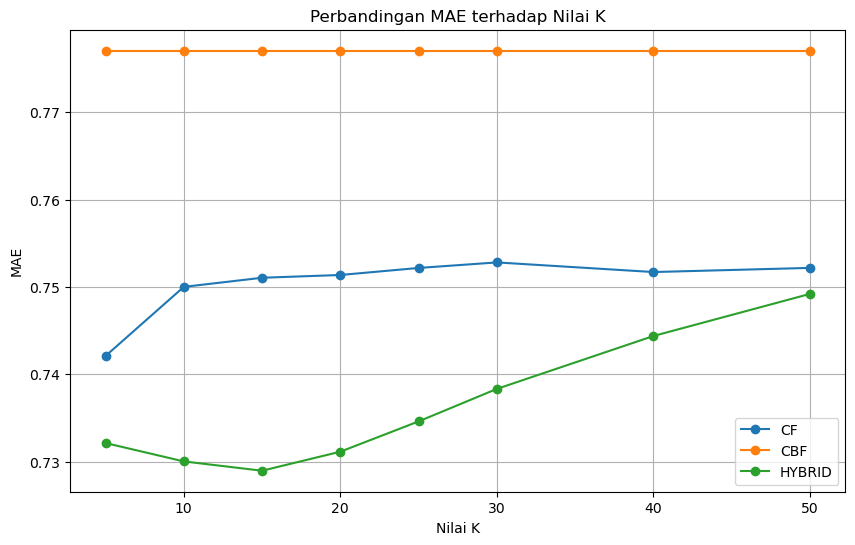

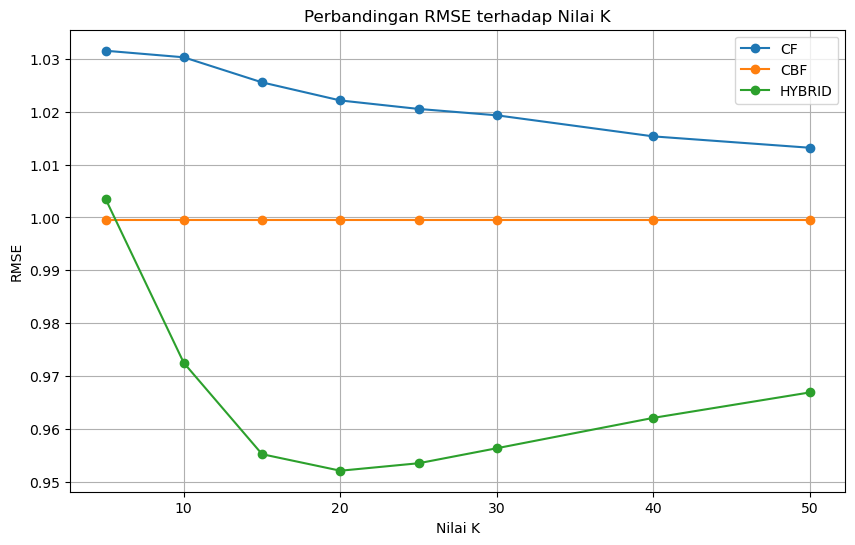

In [96]:
# =========================================================
# IMPORT LIBRARY
# =========================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error
)

# =========================================================
# ACTIVE USERS (>5 RATING)
# =========================================================
user_rating_counts = df_reviews['user_id'].value_counts()

active_users = user_rating_counts[
    user_rating_counts > 5
].index

print("===== ACTIVE USER INFO =====")

print(f"Total Seluruh User : {df_reviews['user_id'].nunique()}")

print(f"Total Active Users (>5 rating) : {len(active_users)}")

# =========================================================
# GLOBAL MEAN
# =========================================================
global_mean_rating = df_reviews['overall'].mean()

# =========================================================
# RANGE K
# =========================================================
k_values_to_test = [5, 10, 15, 20, 25, 30, 40, 50]

# =========================================================
# FILE OUTPUT
# =========================================================
csv_filename = "hasil_k_tuning.csv"

# =========================================================
# CEK FILE LAMA
# =========================================================
try:

    old_results_df = pd.read_csv(csv_filename)

    results_k_tuning = old_results_df.to_dict('records')

    completed_k = old_results_df['K'].tolist()

    print("\nFile hasil lama ditemukan.")

    print(f"K yang sudah selesai: {completed_k}")

except:

    results_k_tuning = []

    completed_k = []

    print("\nBelum ada file hasil sebelumnya.")

# =========================================================
# LOOP K
# =========================================================
for current_k in k_values_to_test:

    # ================================================
    # SKIP JIKA SUDAH ADA
    # ================================================
    if current_k in completed_k:

        print(f"\nK={current_k} sudah pernah selesai. Skip.")

        continue

    print("\n======================================")
    print(f"START EVALUATION K = {current_k}")
    print("======================================")

    # ================================================
    # PENYIMPAN
    # ================================================
    all_actual_ratings = []

    all_predicted_cf = []
    all_predicted_cbf = []
    all_predicted_hybrid = []

    # ================================================
    # COUNTER USER
    # ================================================
    total_active_users = len(active_users)

    # ================================================
    # LOOP ACTIVE USERS
    # ================================================
    for user_counter, target_user_id in enumerate(active_users):

        # ============================================
        # PROGRESS
        # ============================================
        if user_counter % 50 == 0:

            print(
                f"K={current_k} | "
                f"User {user_counter}/{total_active_users}"
            )

        try:

            # ========================================
            # VALIDASI USER
            # ========================================
            if target_user_id not in user_to_index:
                continue

            current_user_index = user_to_index[
                target_user_id
            ]

            # ========================================
            # AMBIL RATING USER
            # ========================================
            target_user_all_ratings = df_reviews[
                df_reviews['user_id']
                == target_user_id
            ]

            if target_user_all_ratings.empty:
                continue

            # ========================================
            # DYNAMIC WEIGHT
            # ========================================
            num_rated = (
                target_user_all_ratings.shape[0]
            )

            Au = min(
                (num_rated / current_k),
                1
            ) * 0.9

            bobot_cf = Au

            bobot_cbf = 1 - Au

            # ========================================
            # HITUNG SIMILAR USER SEKALI
            # ========================================
            similar_users_cf, scores_cf = (
                get_similar_users(
                    current_user_index,
                    user_item_matrix,
                    top_k=current_k
                )
            )

            # ========================================
            # LOOCV
            # ========================================
            for idx, row in (
                target_user_all_ratings.iterrows()
            ):

                left_out_offering_id = (
                    row['offering_id']
                )

                actual_rating = row['overall']

                # ====================================
                # ITEM CODE
                # ====================================
                left_out_item_code = (
                    item_to_code.get(
                        left_out_offering_id
                    )
                )

                if left_out_item_code is None:
                    continue

                # ====================================
                # CF PREDICTION
                # ====================================
                cf_pred = (
                    get_cf_prediction_for_item(
                        current_user_index,
                        left_out_item_code,
                        user_item_matrix,
                        similar_users_cf,
                        scores_cf
                    )
                )

                cf_pred = max(
                    1.0,
                    min(5.0, cf_pred)
                )

                # ====================================
                # CBF PREDICTION
                # ====================================
                user_data_loo = (
                    target_user_all_ratings[
                        target_user_all_ratings[
                            'offering_id'
                        ]
                        != left_out_offering_id
                    ]
                )

                user_mean = (
                    user_data_loo['overall'].mean()
                    if not user_data_loo.empty
                    else global_mean_rating
                )

                numerator = 0

                denominator = 0

                if (
                    left_out_offering_id
                    not in hotel_encoded.index
                ):

                    cbf_pred = (
                        global_mean_rating
                    )

                else:

                    for _, ud_row in (
                        user_data_loo.iterrows()
                    ):

                        rated_hotel = (
                            ud_row['offering_id']
                        )

                        rating = ud_row['overall']

                        if (
                            rated_hotel
                            in similarity_hotel_df.columns
                        ):

                            sim = (
                                similarity_hotel_df.loc[
                                    left_out_offering_id,
                                    rated_hotel
                                ]
                            )

                            if sim > SIM_THRESHOLD:

                                numerator += (
                                    sim *
                                    (
                                        rating
                                        - user_mean
                                    )
                                )

                                denominator += sim

                    if denominator != 0:

                        cbf_pred = (
                            user_mean
                            +
                            (
                                numerator
                                / denominator
                            )
                        )

                    else:

                        cbf_pred = (
                            global_mean_rating
                        )

                cbf_pred = max(
                    1.0,
                    min(5.0, cbf_pred)
                )

                # ====================================
                # HYBRID
                # ====================================
                hybrid_pred = (
                    (bobot_cf * cf_pred)
                    +
                    (bobot_cbf * cbf_pred)
                )

                # ====================================
                # SIMPAN
                # ====================================
                all_actual_ratings.append(
                    actual_rating
                )

                all_predicted_cf.append(
                    cf_pred
                )

                all_predicted_cbf.append(
                    cbf_pred
                )

                all_predicted_hybrid.append(
                    hybrid_pred
                )

        except Exception as e:

            print(
                f"ERROR user "
                f"{target_user_id}: {e}"
            )

            continue

    # =====================================================
    # HITUNG METRIK
    # =====================================================
    if len(all_actual_ratings) > 0:

        mae_cf = mean_absolute_error(
            all_actual_ratings,
            all_predicted_cf
        )

        rmse_cf = np.sqrt(
            mean_squared_error(
                all_actual_ratings,
                all_predicted_cf
            )
        )

        mae_cbf = mean_absolute_error(
            all_actual_ratings,
            all_predicted_cbf
        )

        rmse_cbf = np.sqrt(
            mean_squared_error(
                all_actual_ratings,
                all_predicted_cbf
            )
        )

        mae_hybrid = mean_absolute_error(
            all_actual_ratings,
            all_predicted_hybrid
        )

        rmse_hybrid = np.sqrt(
            mean_squared_error(
                all_actual_ratings,
                all_predicted_hybrid
            )
        )

        # =================================================
        # SIMPAN HASIL
        # =================================================
        result_row = {

            'K': current_k,

            'MAE_CF': mae_cf,
            'RMSE_CF': rmse_cf,

            'MAE_CBF': mae_cbf,
            'RMSE_CBF': rmse_cbf,

            'MAE_HYBRID': mae_hybrid,
            'RMSE_HYBRID': rmse_hybrid
        }

        results_k_tuning.append(
            result_row
        )

        # =================================================
        # SAVE CSV SETELAH SETIAP K
        # =================================================
        results_df = pd.DataFrame(
            results_k_tuning
        )

        results_df.to_csv(
            csv_filename,
            index=False
        )

        print("\n===== HASIL K =====")

        print(result_row)

        print(
            f"\nHASIL DISIMPAN "
            f"KE {csv_filename}"
        )

    else:

        print(
            f"Tidak ada hasil "
            f"untuk K={current_k}"
        )

# =========================================================
# HASIL FINAL
# =========================================================
results_df = pd.DataFrame(
    results_k_tuning
)

print("\n======================================")
print("FINAL RESULTS")
print("======================================")

print(results_df)

# =========================================================
# BEST K
# =========================================================
if not results_df.empty:

    best_k = results_df.loc[
        results_df['MAE_HYBRID'].idxmin()
    ]

    print("\n===== BEST K HYBRID =====")

    print(best_k)

# =========================================================
# GRAFIK MAE
# =========================================================
if not results_df.empty:

    plt.figure(figsize=(10,6))

    plt.plot(
        results_df['K'],
        results_df['MAE_CF'],
        marker='o',
        label='CF'
    )

    plt.plot(
        results_df['K'],
        results_df['MAE_CBF'],
        marker='o',
        label='CBF'
    )

    plt.plot(
        results_df['K'],
        results_df['MAE_HYBRID'],
        marker='o',
        label='HYBRID'
    )

    plt.xlabel('Nilai K')

    plt.ylabel('MAE')

    plt.title(
        'Perbandingan MAE terhadap Nilai K'
    )

    plt.legend()

    plt.grid(True)

    plt.show()

# =========================================================
# GRAFIK RMSE
# =========================================================
if not results_df.empty:

    plt.figure(figsize=(10,6))

    plt.plot(
        results_df['K'],
        results_df['RMSE_CF'],
        marker='o',
        label='CF'
    )

    plt.plot(
        results_df['K'],
        results_df['RMSE_CBF'],
        marker='o',
        label='CBF'
    )

    plt.plot(
        results_df['K'],
        results_df['RMSE_HYBRID'],
        marker='o',
        label='HYBRID'
    )

    plt.xlabel('Nilai K')

    plt.ylabel('RMSE')

    plt.title(
        'Perbandingan RMSE terhadap Nilai K'
    )

    plt.legend()

    plt.grid(True)

    plt.show()

===== ACTIVE USER INFO =====
Total Seluruh User : 575853
Total Active Users (>5 rating) : 21958

Belum ada file hasil sebelumnya.

START EVALUATION K = 5
K=5 | User 0/21958
K=5 | User 50/21958
K=5 | User 100/21958
K=5 | User 150/21958
K=5 | User 200/21958
K=5 | User 250/21958
K=5 | User 300/21958
K=5 | User 350/21958
K=5 | User 400/21958
K=5 | User 450/21958
K=5 | User 500/21958
K=5 | User 550/21958
K=5 | User 600/21958
K=5 | User 650/21958
K=5 | User 700/21958
K=5 | User 750/21958
K=5 | User 800/21958
K=5 | User 850/21958
K=5 | User 900/21958
K=5 | User 950/21958
K=5 | User 1000/21958
K=5 | User 1050/21958
K=5 | User 1100/21958
K=5 | User 1150/21958
K=5 | User 1200/21958
K=5 | User 1250/21958
K=5 | User 1300/21958
K=5 | User 1350/21958
K=5 | User 1400/21958
K=5 | User 1450/21958
K=5 | User 1500/21958
K=5 | User 1550/21958
K=5 | User 1600/21958
K=5 | User 1650/21958
K=5 | User 1700/21958
K=5 | User 1750/21958
K=5 | User 1800/21958
K=5 | User 1850/21958
K=5 | User 1900/21958
K=5 | User 

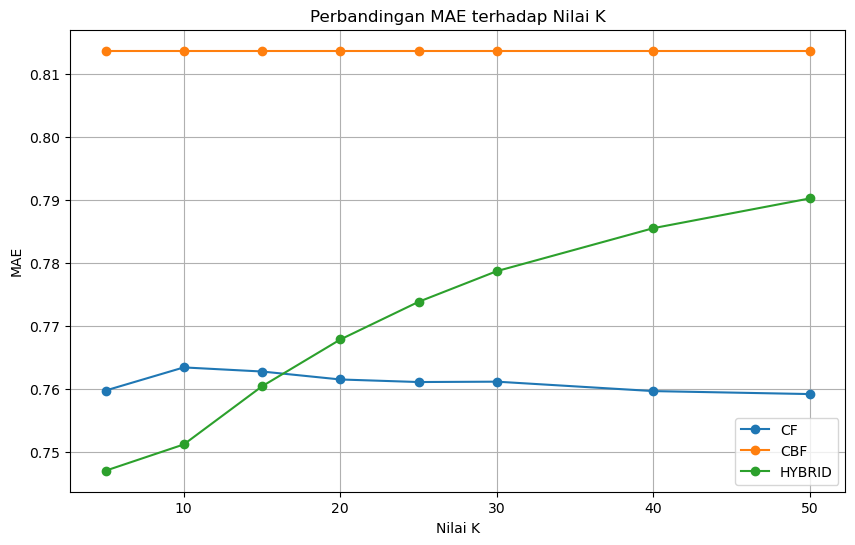

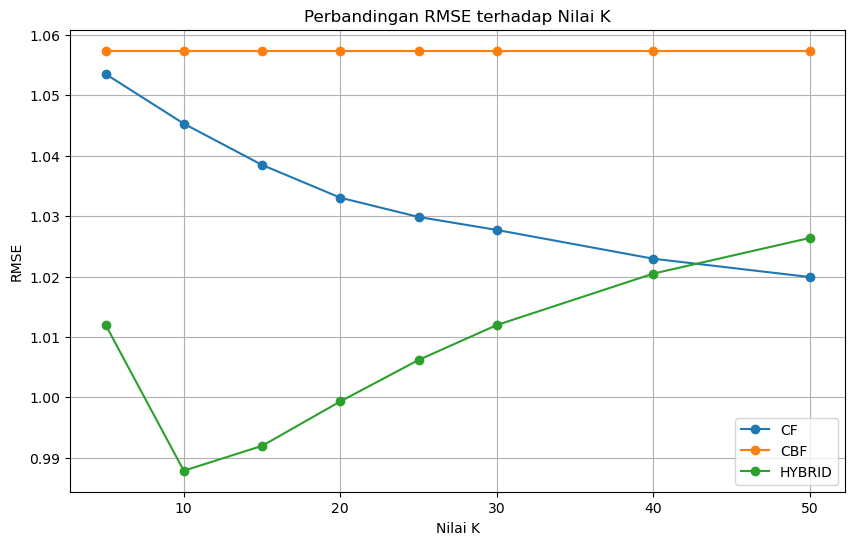

In [98]:
# =========================================================
# IMPORT LIBRARY
# =========================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error
)

# =========================================================
# ACTIVE USERS (>5 RATING)
# =========================================================
user_rating_counts = df_reviews['user_id'].value_counts()

active_users = user_rating_counts[
    user_rating_counts > 3
].index

print("===== ACTIVE USER INFO =====")

print(f"Total Seluruh User : {df_reviews['user_id'].nunique()}")

print(f"Total Active Users (>5 rating) : {len(active_users)}")

# =========================================================
# GLOBAL MEAN
# =========================================================
global_mean_rating = df_reviews['overall'].mean()

# =========================================================
# RANGE K
# =========================================================
k_values_to_test = [5, 10, 15, 20, 25, 30, 40, 50]

# =========================================================
# FILE OUTPUT
# =========================================================
csv_filename = "hasil_k_tuning_RatingBesar3.csv"

# =========================================================
# CEK FILE LAMA
# =========================================================
try:

    old_results_df = pd.read_csv(csv_filename)

    results_k_tuning = old_results_df.to_dict('records')

    completed_k = old_results_df['K'].tolist()

    print("\nFile hasil lama ditemukan.")

    print(f"K yang sudah selesai: {completed_k}")

except:

    results_k_tuning = []

    completed_k = []

    print("\nBelum ada file hasil sebelumnya.")

# =========================================================
# LOOP K
# =========================================================
for current_k in k_values_to_test:

    # ================================================
    # SKIP JIKA SUDAH ADA
    # ================================================
    if current_k in completed_k:

        print(f"\nK={current_k} sudah pernah selesai. Skip.")

        continue

    print("\n======================================")
    print(f"START EVALUATION K = {current_k}")
    print("======================================")

    # ================================================
    # PENYIMPAN
    # ================================================
    all_actual_ratings = []

    all_predicted_cf = []
    all_predicted_cbf = []
    all_predicted_hybrid = []

    # ================================================
    # COUNTER USER
    # ================================================
    total_active_users = len(active_users)

    # ================================================
    # LOOP ACTIVE USERS
    # ================================================
    for user_counter, target_user_id in enumerate(active_users):

        # ============================================
        # PROGRESS
        # ============================================
        if user_counter % 50 == 0:

            print(
                f"K={current_k} | "
                f"User {user_counter}/{total_active_users}"
            )

        try:

            # ========================================
            # VALIDASI USER
            # ========================================
            if target_user_id not in user_to_index:
                continue

            current_user_index = user_to_index[
                target_user_id
            ]

            # ========================================
            # AMBIL RATING USER
            # ========================================
            target_user_all_ratings = df_reviews[
                df_reviews['user_id']
                == target_user_id
            ]

            if target_user_all_ratings.empty:
                continue

            # ========================================
            # DYNAMIC WEIGHT
            # ========================================
            num_rated = (
                target_user_all_ratings.shape[0]
            )

            Au = min(
                (num_rated / current_k),
                1
            ) * 0.9

            bobot_cf = Au

            bobot_cbf = 1 - Au

            # ========================================
            # HITUNG SIMILAR USER SEKALI
            # ========================================
            similar_users_cf, scores_cf = (
                get_similar_users(
                    current_user_index,
                    user_item_matrix,
                    top_k=current_k
                )
            )

            # ========================================
            # LOOCV
            # ========================================
            for idx, row in (
                target_user_all_ratings.iterrows()
            ):

                left_out_offering_id = (
                    row['offering_id']
                )

                actual_rating = row['overall']

                # ====================================
                # ITEM CODE
                # ====================================
                left_out_item_code = (
                    item_to_code.get(
                        left_out_offering_id
                    )
                )

                if left_out_item_code is None:
                    continue

                # ====================================
                # CF PREDICTION
                # ====================================
                cf_pred = (
                    get_cf_prediction_for_item(
                        current_user_index,
                        left_out_item_code,
                        user_item_matrix,
                        similar_users_cf,
                        scores_cf
                    )
                )

                cf_pred = max(
                    1.0,
                    min(5.0, cf_pred)
                )

                # ====================================
                # CBF PREDICTION
                # ====================================
                user_data_loo = (
                    target_user_all_ratings[
                        target_user_all_ratings[
                            'offering_id'
                        ]
                        != left_out_offering_id
                    ]
                )

                user_mean = (
                    user_data_loo['overall'].mean()
                    if not user_data_loo.empty
                    else global_mean_rating
                )

                numerator = 0

                denominator = 0

                if (
                    left_out_offering_id
                    not in hotel_encoded.index
                ):

                    cbf_pred = (
                        global_mean_rating
                    )

                else:

                    for _, ud_row in (
                        user_data_loo.iterrows()
                    ):

                        rated_hotel = (
                            ud_row['offering_id']
                        )

                        rating = ud_row['overall']

                        if (
                            rated_hotel
                            in similarity_hotel_df.columns
                        ):

                            sim = (
                                similarity_hotel_df.loc[
                                    left_out_offering_id,
                                    rated_hotel
                                ]
                            )

                            if sim > SIM_THRESHOLD:

                                numerator += (
                                    sim *
                                    (
                                        rating
                                        - user_mean
                                    )
                                )

                                denominator += sim

                    if denominator != 0:

                        cbf_pred = (
                            user_mean
                            +
                            (
                                numerator
                                / denominator
                            )
                        )

                    else:

                        cbf_pred = (
                            global_mean_rating
                        )

                cbf_pred = max(
                    1.0,
                    min(5.0, cbf_pred)
                )

                # ====================================
                # HYBRID
                # ====================================
                hybrid_pred = (
                    (bobot_cf * cf_pred)
                    +
                    (bobot_cbf * cbf_pred)
                )

                # ====================================
                # SIMPAN
                # ====================================
                all_actual_ratings.append(
                    actual_rating
                )

                all_predicted_cf.append(
                    cf_pred
                )

                all_predicted_cbf.append(
                    cbf_pred
                )

                all_predicted_hybrid.append(
                    hybrid_pred
                )

        except Exception as e:

            print(
                f"ERROR user "
                f"{target_user_id}: {e}"
            )

            continue

    # =====================================================
    # HITUNG METRIK
    # =====================================================
    if len(all_actual_ratings) > 0:

        mae_cf = mean_absolute_error(
            all_actual_ratings,
            all_predicted_cf
        )

        rmse_cf = np.sqrt(
            mean_squared_error(
                all_actual_ratings,
                all_predicted_cf
            )
        )

        mae_cbf = mean_absolute_error(
            all_actual_ratings,
            all_predicted_cbf
        )

        rmse_cbf = np.sqrt(
            mean_squared_error(
                all_actual_ratings,
                all_predicted_cbf
            )
        )

        mae_hybrid = mean_absolute_error(
            all_actual_ratings,
            all_predicted_hybrid
        )

        rmse_hybrid = np.sqrt(
            mean_squared_error(
                all_actual_ratings,
                all_predicted_hybrid
            )
        )

        # =================================================
        # SIMPAN HASIL
        # =================================================
        result_row = {

            'K': current_k,

            'MAE_CF': mae_cf,
            'RMSE_CF': rmse_cf,

            'MAE_CBF': mae_cbf,
            'RMSE_CBF': rmse_cbf,

            'MAE_HYBRID': mae_hybrid,
            'RMSE_HYBRID': rmse_hybrid
        }

        results_k_tuning.append(
            result_row
        )

        # =================================================
        # SAVE CSV SETELAH SETIAP K
        # =================================================
        results_df = pd.DataFrame(
            results_k_tuning
        )

        results_df.to_csv(
            csv_filename,
            index=False
        )

        print("\n===== HASIL K =====")

        print(result_row)

        print(
            f"\nHASIL DISIMPAN "
            f"KE {csv_filename}"
        )

    else:

        print(
            f"Tidak ada hasil "
            f"untuk K={current_k}"
        )

# =========================================================
# HASIL FINAL
# =========================================================
results_df = pd.DataFrame(
    results_k_tuning
)

print("\n======================================")
print("FINAL RESULTS")
print("======================================")

print(results_df)

# =========================================================
# BEST K
# =========================================================
if not results_df.empty:

    best_k = results_df.loc[
        results_df['MAE_HYBRID'].idxmin()
    ]

    print("\n===== BEST K HYBRID =====")

    print(best_k)

# =========================================================
# GRAFIK MAE
# =========================================================
if not results_df.empty:

    plt.figure(figsize=(10,6))

    plt.plot(
        results_df['K'],
        results_df['MAE_CF'],
        marker='o',
        label='CF'
    )

    plt.plot(
        results_df['K'],
        results_df['MAE_CBF'],
        marker='o',
        label='CBF'
    )

    plt.plot(
        results_df['K'],
        results_df['MAE_HYBRID'],
        marker='o',
        label='HYBRID'
    )

    plt.xlabel('Nilai K')

    plt.ylabel('MAE')

    plt.title(
        'Perbandingan MAE terhadap Nilai K'
    )

    plt.legend()

    plt.grid(True)

    plt.show()

# =========================================================
# GRAFIK RMSE
# =========================================================
if not results_df.empty:

    plt.figure(figsize=(10,6))

    plt.plot(
        results_df['K'],
        results_df['RMSE_CF'],
        marker='o',
        label='CF'
    )

    plt.plot(
        results_df['K'],
        results_df['RMSE_CBF'],
        marker='o',
        label='CBF'
    )

    plt.plot(
        results_df['K'],
        results_df['RMSE_HYBRID'],
        marker='o',
        label='HYBRID'
    )

    plt.xlabel('Nilai K')

    plt.ylabel('RMSE')

    plt.title(
        'Perbandingan RMSE terhadap Nilai K'
    )

    plt.legend()

    plt.grid(True)

    plt.show()